In [6]:
import pandas as pd

file_path = "C:/Users/ramch/OneDrive/Desktop/Internship_Project/Processed_Flipdata.csv"
df = pd.read_csv(file_path)

In [5]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   Unnamed: 0            Model        Colour  Memory  RAM  Battery_  \
0           0  Infinix SMART 7   Night Black      64    4      6000   
1           1  Infinix SMART 7    Azure Blue      64    4      6000   
2           2     MOTOROLA G32  Mineral Gray     128    8      5000   
3           3         POCO C50    Royal Blue      32    2      5000   
4           4  Infinix HOT 30i      Marigold     128    8      5000   

  Rear Camera Front Camera  AI Lens  Mobile Height  \
0        13MP          5MP        1          16.76   
1        13MP          5MP        1          16.76   
2        50MP         16MP        0          16.64   
3         8MP          5MP        0          16.56   
4        50MP          5MP        1          16.76   

                   Processor_   Prize  
0  Unisoc Spreadtrum SC9863A1   7,299  
1  Unisoc Spreadtrum SC9863A1   7,299  
2     Qualcomm Snapdragon 680  11,999  
3          Mediatek Helio A22   5,649  
4                         G37   8,999  
(541, 12

   Unnamed: 0            Model        Colour  Memory  RAM  Battery_  \
0           0  Infinix SMART 7   Night Black      64    4      6000   
1           1  Infinix SMART 7    Azure Blue      64    4      6000   
2           2     MOTOROLA G32  Mineral Gray     128    8      5000   
3           3         POCO C50    Royal Blue      32    2      5000   
4           4  Infinix HOT 30i      Marigold     128    8      5000   

  Rear Camera Front Camera  AI Lens  Mobile Height  \
0        13MP          5MP        1          16.76   
1        13MP          5MP        1          16.76   
2        50MP         16MP        0          16.64   
3         8MP          5MP        0          16.56   
4        50MP          5MP        1          16.76   

                   Processor_   Prize  
0  Unisoc Spreadtrum SC9863A1   7,299  
1  Unisoc Spreadtrum SC9863A1   7,299  
2     Qualcomm Snapdragon 680  11,999  
3          Mediatek Helio A22   5,649  
4                         G37   8,999  
      Co

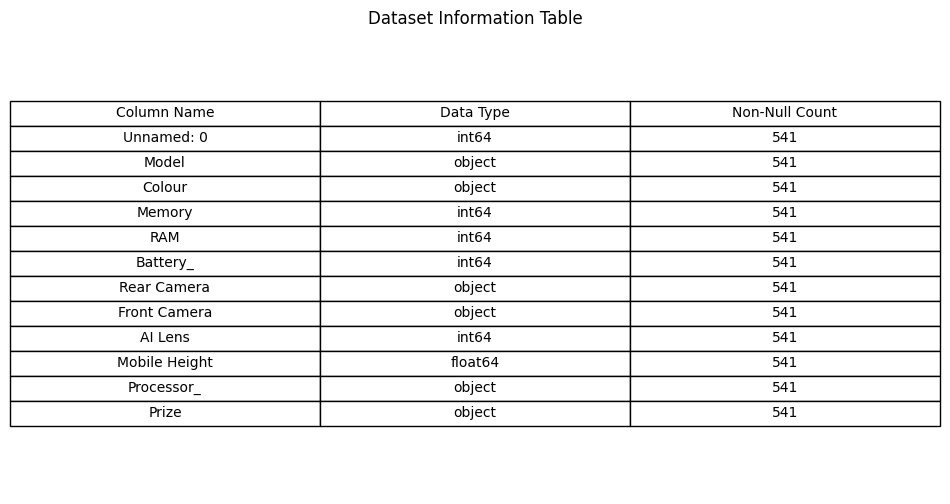

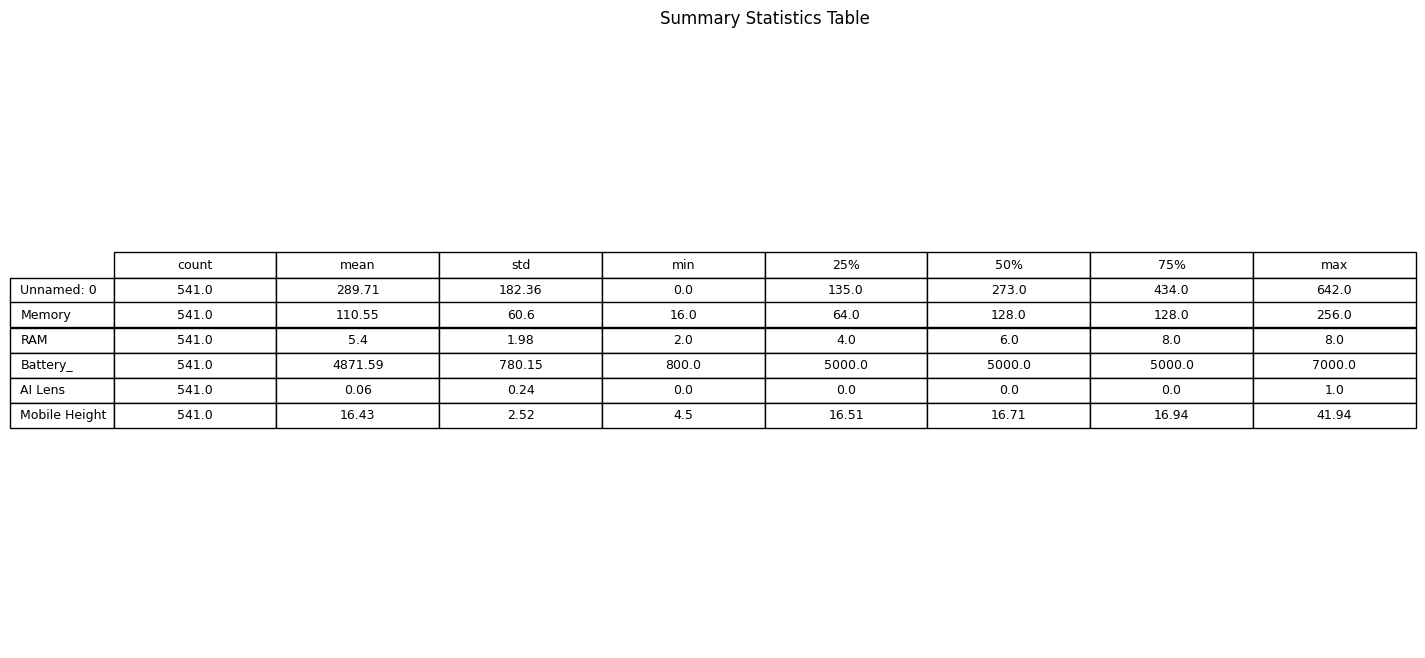

In [3]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load Dataset
# -----------------------------
# Replace with your actual file path
df = pd.read_csv("C:/Users/ramch/OneDrive/Desktop/Internship_Project/Processed_Flipdata.csv")

# Example:
# df = pd.read_csv(r"C:\Users\YourName\Desktop\mobile_data.csv")

# -----------------------------
# 2. Display first few rows
# -----------------------------
print(df.head())

# -----------------------------
# 3. Dataset Information Table
# -----------------------------
info_df = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.count().values
})

print(info_df)

# -----------------------------
# 4. Descriptive Statistics Table
# -----------------------------
summary_table = df.describe().transpose()

print(summary_table)

# -----------------------------
# 5. Save Dataset Info Table
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

table = ax.table(
    cellText=info_df.values,
    colLabels=info_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Dataset Information Table")
plt.savefig("dataset_info_table.png", dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# 6. Save Summary Statistics Table
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

table2 = ax.table(
    cellText=summary_table.round(2).values,
    rowLabels=summary_table.index,
    colLabels=summary_table.columns,
    cellLoc='center',
    loc='center'
)

table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1.2, 1.5)

plt.title("Summary Statistics Table")
plt.savefig("summary_statistics_table.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
print(df.isnull().sum())

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64


In [8]:
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=['int64','float64']):
    df[col] = df[col].fillna(df[col].median())

In [9]:
df.drop_duplicates(inplace=True)

In [11]:
# Select only numeric columns first
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate quartiles
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

# Remove outliers using IQR method
filtered_df = numeric_df[
    ~((numeric_df < (Q1 - 1.5 * IQR)) |
      (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)
]

print(filtered_df.shape)

(338, 6)


In [12]:
df_encoded = pd.get_dummies(df, drop_first=True)

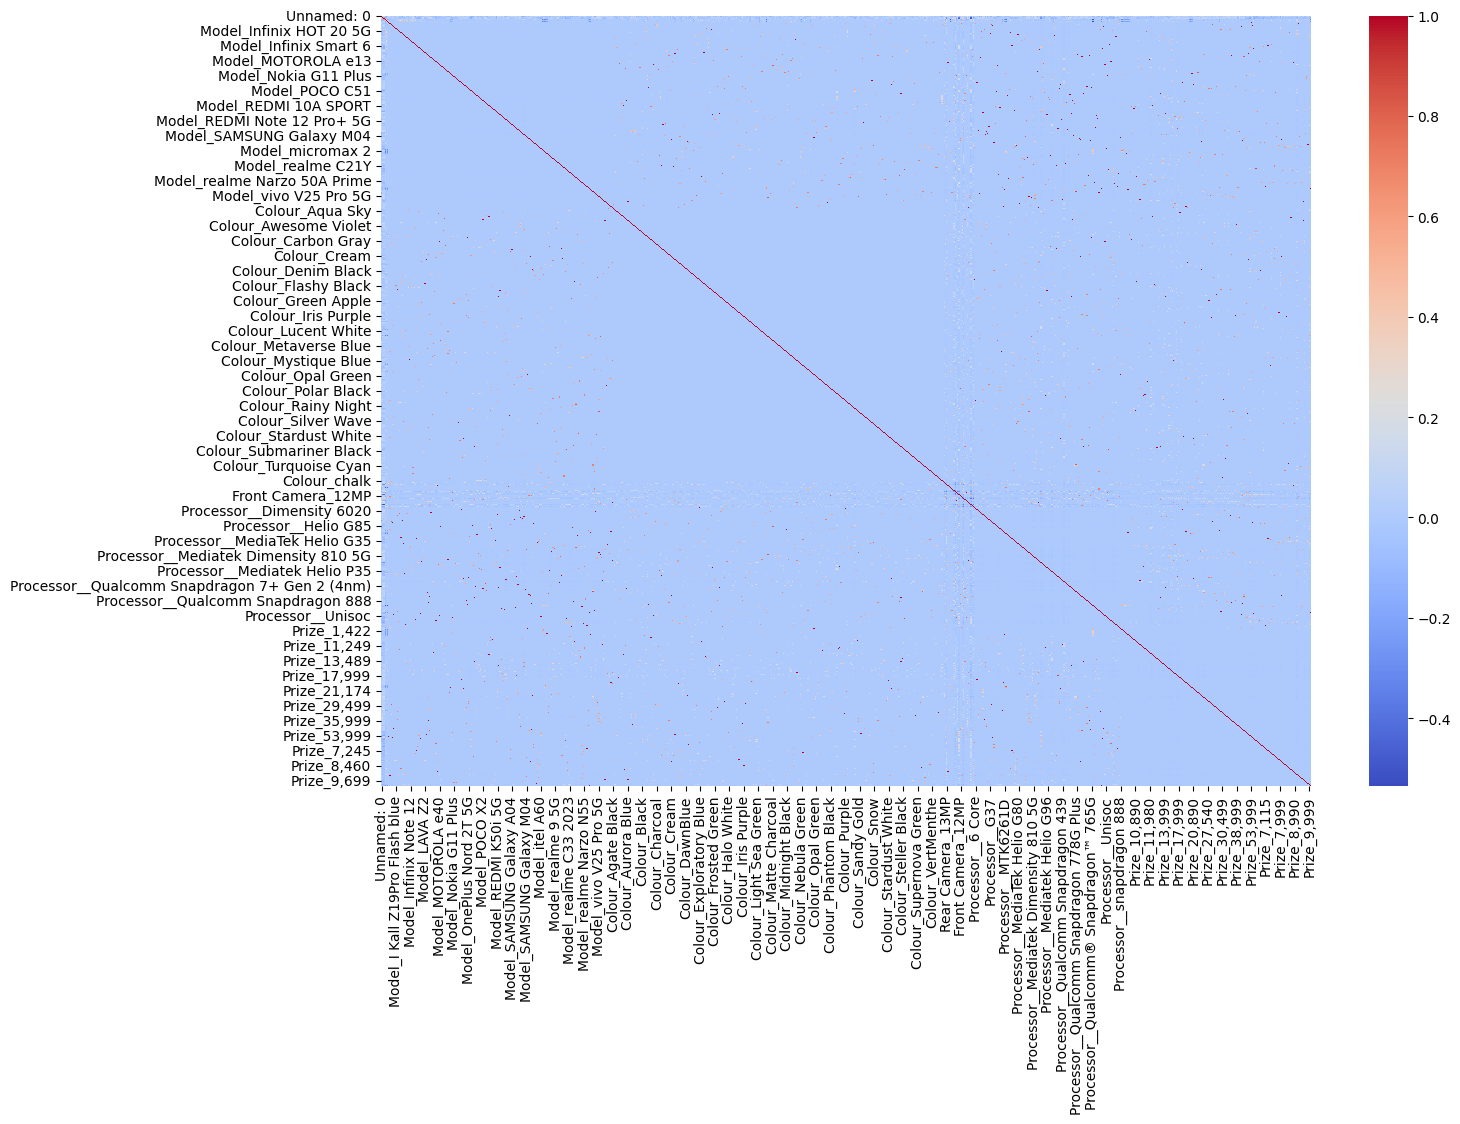

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_encoded.corr()

plt.figure(figsize=(15,10))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [16]:
print(df_encoded.columns)

Index(['Unnamed: 0', 'Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height',
       'Model_APPLE iPhone 12', 'Model_APPLE iPhone 14 Plus',
       'Model_Google Pixel 6a', 'Model_Google Pixel 7',
       ...
       'Prize_9,104', 'Prize_9,290', 'Prize_9,349', 'Prize_9,387',
       'Prize_9,499', 'Prize_9,699', 'Prize_9,790', 'Prize_9,990',
       'Prize_9,999', 'Prize_920'],
      dtype='object', length=770)


In [18]:
print(df_encoded.columns.tolist())

['Unnamed: 0', 'Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height', 'Model_APPLE iPhone 12', 'Model_APPLE iPhone 14 Plus', 'Model_Google Pixel 6a', 'Model_Google Pixel 7', 'Model_Google Pixel 7a', 'Model_I Kall Z19Pro', 'Model_I Kall Z19Pro Flash blue', 'Model_IQOO Neo 7 5G', 'Model_Infinix HOT 12 Play', 'Model_Infinix HOT 20 5G', 'Model_Infinix HOT 20 Play', 'Model_Infinix HOT 30i', 'Model_Infinix Hot 11', 'Model_Infinix Hot 12', 'Model_Infinix Hot 12 Pro', 'Model_Infinix Hot 20 5G', 'Model_Infinix NOTE 12i', 'Model_Infinix Note 11s Free Fire Edition', 'Model_Infinix Note 12', 'Model_Infinix Note 12 5G', 'Model_Infinix Note 12 Pro', 'Model_Infinix Note 12 Pro 5G', 'Model_Infinix SMART 7', 'Model_Infinix Smart 5A', 'Model_Infinix Smart 6', 'Model_Infinix Smart 6 HD', 'Model_Infinix Smart 7 HD', 'Model_Infinix Zero 20', 'Model_Infinix Zero 5G 2023', 'Model_Infinix Zero 5G 2023 TURBO', 'Model_LAVA Z2', 'Model_LAVA Z21', 'Model_MOTOROLA Edge 30', 'Model_MOTOROLA Edge 30 Fusion', 'Mode

In [20]:
df_encoded.columns = df_encoded.columns.str.strip().str.lower()
print(df_encoded.columns)

Index(['unnamed: 0', 'memory', 'ram', 'battery_', 'ai lens', 'mobile height',
       'model_apple iphone 12', 'model_apple iphone 14 plus',
       'model_google pixel 6a', 'model_google pixel 7',
       ...
       'prize_9,104', 'prize_9,290', 'prize_9,349', 'prize_9,387',
       'prize_9,499', 'prize_9,699', 'prize_9,790', 'prize_9,990',
       'prize_9,999', 'prize_920'],
      dtype='object', length=770)


In [25]:
for col in df_encoded.columns:
    if 'prize' in col.lower():
        print(col)

prize_1,299
prize_1,375
prize_1,422
prize_1,449
prize_1,599
prize_1,699
prize_1,849
prize_10,499
prize_10,548
prize_10,699
prize_10,799
prize_10,890
prize_10,943
prize_10,989
prize_10,999
prize_11,209
prize_11,248
prize_11,249
prize_11,349
prize_11,490
prize_11,499
prize_11,762
prize_11,970
prize_11,980
prize_11,999
prize_12,272
prize_12,499
prize_12,599
prize_12,900
prize_12,989
prize_12,990
prize_12,999
prize_13,489
prize_13,490
prize_13,499
prize_13,999
prize_14,385
prize_14,490
prize_14,499
prize_14,999
prize_15,499
prize_15,999
prize_16,499
prize_16,988
prize_16,990
prize_16,999
prize_17,499
prize_17,999
prize_18,990
prize_18,999
prize_19,280
prize_19,397
prize_19,499
prize_19,979
prize_19,990
prize_19,999
prize_2,490
prize_2,499
prize_2,615
prize_20,890
prize_20,998
prize_20,999
prize_21,174
prize_21,499
prize_21,999
prize_22,999
prize_23,390
prize_23,999
prize_24,999
prize_25,999
prize_26,999
prize_27,540
prize_27,877
prize_27,999
prize_28,298
prize_28,999
prize_29,418
prize_29,

In [29]:
print(df_encoded.columns.tolist())

['unnamed: 0', 'memory', 'ram', 'battery_', 'ai lens', 'mobile height', 'model_apple iphone 12', 'model_apple iphone 14 plus', 'model_google pixel 6a', 'model_google pixel 7', 'model_google pixel 7a', 'model_i kall z19pro', 'model_i kall z19pro flash blue', 'model_iqoo neo 7 5g', 'model_infinix hot 12 play', 'model_infinix hot 20 5g', 'model_infinix hot 20 play', 'model_infinix hot 30i', 'model_infinix hot 11', 'model_infinix hot 12', 'model_infinix hot 12 pro', 'model_infinix hot 20 5g', 'model_infinix note 12i', 'model_infinix note 11s free fire edition', 'model_infinix note 12', 'model_infinix note 12 5g', 'model_infinix note 12 pro', 'model_infinix note 12 pro 5g', 'model_infinix smart 7', 'model_infinix smart 5a', 'model_infinix smart 6', 'model_infinix smart 6 hd', 'model_infinix smart 7 hd', 'model_infinix zero 20', 'model_infinix zero 5g 2023', 'model_infinix zero 5g 2023 turbo', 'model_lava z2', 'model_lava z21', 'model_motorola edge 30', 'model_motorola edge 30 fusion', 'mode

In [30]:
# Print all columns one by one
for col in df_encoded.columns:
    print(f"'{col}'")

'unnamed: 0'
'memory'
'ram'
'battery_'
'ai lens'
'mobile height'
'model_apple iphone 12'
'model_apple iphone 14 plus'
'model_google pixel 6a'
'model_google pixel 7'
'model_google pixel 7a'
'model_i kall z19pro'
'model_i kall z19pro flash blue'
'model_iqoo neo 7 5g'
'model_infinix hot 12 play'
'model_infinix hot 20 5g'
'model_infinix hot 20 play'
'model_infinix hot 30i'
'model_infinix hot 11'
'model_infinix hot 12'
'model_infinix hot 12 pro'
'model_infinix hot 20 5g'
'model_infinix note 12i'
'model_infinix note 11s free fire edition'
'model_infinix note 12'
'model_infinix note 12 5g'
'model_infinix note 12 pro'
'model_infinix note 12 pro 5g'
'model_infinix smart 7'
'model_infinix smart 5a'
'model_infinix smart 6'
'model_infinix smart 6 hd'
'model_infinix smart 7 hd'
'model_infinix zero 20'
'model_infinix zero 5g 2023'
'model_infinix zero 5g 2023 turbo'
'model_lava z2'
'model_lava z21'
'model_motorola edge 30'
'model_motorola edge 30 fusion'
'model_motorola edge 30 ultra'
'model_motorola

In [31]:
df_encoded.columns = df_encoded.columns.str.strip()

In [32]:
print(df_encoded.columns.tolist())

['unnamed: 0', 'memory', 'ram', 'battery_', 'ai lens', 'mobile height', 'model_apple iphone 12', 'model_apple iphone 14 plus', 'model_google pixel 6a', 'model_google pixel 7', 'model_google pixel 7a', 'model_i kall z19pro', 'model_i kall z19pro flash blue', 'model_iqoo neo 7 5g', 'model_infinix hot 12 play', 'model_infinix hot 20 5g', 'model_infinix hot 20 play', 'model_infinix hot 30i', 'model_infinix hot 11', 'model_infinix hot 12', 'model_infinix hot 12 pro', 'model_infinix hot 20 5g', 'model_infinix note 12i', 'model_infinix note 11s free fire edition', 'model_infinix note 12', 'model_infinix note 12 5g', 'model_infinix note 12 pro', 'model_infinix note 12 pro 5g', 'model_infinix smart 7', 'model_infinix smart 5a', 'model_infinix smart 6', 'model_infinix smart 6 hd', 'model_infinix smart 7 hd', 'model_infinix zero 20', 'model_infinix zero 5g 2023', 'model_infinix zero 5g 2023 turbo', 'model_lava z2', 'model_lava z21', 'model_motorola edge 30', 'model_motorola edge 30 fusion', 'mode

In [33]:
print(df_encoded.columns.tolist())

['unnamed: 0', 'memory', 'ram', 'battery_', 'ai lens', 'mobile height', 'model_apple iphone 12', 'model_apple iphone 14 plus', 'model_google pixel 6a', 'model_google pixel 7', 'model_google pixel 7a', 'model_i kall z19pro', 'model_i kall z19pro flash blue', 'model_iqoo neo 7 5g', 'model_infinix hot 12 play', 'model_infinix hot 20 5g', 'model_infinix hot 20 play', 'model_infinix hot 30i', 'model_infinix hot 11', 'model_infinix hot 12', 'model_infinix hot 12 pro', 'model_infinix hot 20 5g', 'model_infinix note 12i', 'model_infinix note 11s free fire edition', 'model_infinix note 12', 'model_infinix note 12 5g', 'model_infinix note 12 pro', 'model_infinix note 12 pro 5g', 'model_infinix smart 7', 'model_infinix smart 5a', 'model_infinix smart 6', 'model_infinix smart 6 hd', 'model_infinix smart 7 hd', 'model_infinix zero 20', 'model_infinix zero 5g 2023', 'model_infinix zero 5g 2023 turbo', 'model_lava z2', 'model_lava z21', 'model_motorola edge 30', 'model_motorola edge 30 fusion', 'mode

In [35]:
print(df_encoded.columns)

Index(['unnamed: 0', 'memory', 'ram', 'battery_', 'ai lens', 'mobile height',
       'model_apple iphone 12', 'model_apple iphone 14 plus',
       'model_google pixel 6a', 'model_google pixel 7',
       ...
       'prize_9,104', 'prize_9,290', 'prize_9,349', 'prize_9,387',
       'prize_9,499', 'prize_9,699', 'prize_9,790', 'prize_9,990',
       'prize_9,999', 'prize_920'],
      dtype='object', length=770)


In [36]:
# Clean column names
df_encoded.columns = df_encoded.columns.str.strip()

# Print all columns
print(df_encoded.columns.tolist())

['unnamed: 0', 'memory', 'ram', 'battery_', 'ai lens', 'mobile height', 'model_apple iphone 12', 'model_apple iphone 14 plus', 'model_google pixel 6a', 'model_google pixel 7', 'model_google pixel 7a', 'model_i kall z19pro', 'model_i kall z19pro flash blue', 'model_iqoo neo 7 5g', 'model_infinix hot 12 play', 'model_infinix hot 20 5g', 'model_infinix hot 20 play', 'model_infinix hot 30i', 'model_infinix hot 11', 'model_infinix hot 12', 'model_infinix hot 12 pro', 'model_infinix hot 20 5g', 'model_infinix note 12i', 'model_infinix note 11s free fire edition', 'model_infinix note 12', 'model_infinix note 12 5g', 'model_infinix note 12 pro', 'model_infinix note 12 pro 5g', 'model_infinix smart 7', 'model_infinix smart 5a', 'model_infinix smart 6', 'model_infinix smart 6 hd', 'model_infinix smart 7 hd', 'model_infinix zero 20', 'model_infinix zero 5g 2023', 'model_infinix zero 5g 2023 turbo', 'model_lava z2', 'model_lava z21', 'model_motorola edge 30', 'model_motorola edge 30 fusion', 'mode

In [37]:
for col in df_encoded.columns:
    if 'prize' in col.lower() or 'price' in col.lower():
        print("Target column found:", col)

Target column found: prize_1,299
Target column found: prize_1,375
Target column found: prize_1,422
Target column found: prize_1,449
Target column found: prize_1,599
Target column found: prize_1,699
Target column found: prize_1,849
Target column found: prize_10,499
Target column found: prize_10,548
Target column found: prize_10,699
Target column found: prize_10,799
Target column found: prize_10,890
Target column found: prize_10,943
Target column found: prize_10,989
Target column found: prize_10,999
Target column found: prize_11,209
Target column found: prize_11,248
Target column found: prize_11,249
Target column found: prize_11,349
Target column found: prize_11,490
Target column found: prize_11,499
Target column found: prize_11,762
Target column found: prize_11,970
Target column found: prize_11,980
Target column found: prize_11,999
Target column found: prize_12,272
Target column found: prize_12,499
Target column found: prize_12,599
Target column found: prize_12,900
Target column found: 

In [42]:
print(df_encoded.columns.tolist())

['unnamed: 0', 'memory', 'ram', 'battery_', 'ai lens', 'mobile height', 'model_apple iphone 12', 'model_apple iphone 14 plus', 'model_google pixel 6a', 'model_google pixel 7', 'model_google pixel 7a', 'model_i kall z19pro', 'model_i kall z19pro flash blue', 'model_iqoo neo 7 5g', 'model_infinix hot 12 play', 'model_infinix hot 20 5g', 'model_infinix hot 20 play', 'model_infinix hot 30i', 'model_infinix hot 11', 'model_infinix hot 12', 'model_infinix hot 12 pro', 'model_infinix hot 20 5g', 'model_infinix note 12i', 'model_infinix note 11s free fire edition', 'model_infinix note 12', 'model_infinix note 12 5g', 'model_infinix note 12 pro', 'model_infinix note 12 pro 5g', 'model_infinix smart 7', 'model_infinix smart 5a', 'model_infinix smart 6', 'model_infinix smart 6 hd', 'model_infinix smart 7 hd', 'model_infinix zero 20', 'model_infinix zero 5g 2023', 'model_infinix zero 5g 2023 turbo', 'model_lava z2', 'model_lava z21', 'model_motorola edge 30', 'model_motorola edge 30 fusion', 'mode

In [44]:
# Remove commas from Prize column
df['Prize'] = df['Prize'].astype(str).str.replace(',', '')

# Convert to numeric
df['Prize'] = pd.to_numeric(df['Prize'])

# Check datatype
print(df['Prize'].dtype)

int64


In [45]:
# Target variable
y = df['Prize']

# Feature dataframe
X = df.drop('Prize', axis=1)

# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Feature selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

selector = SelectKBest(score_func=f_regression, k=10)

X_new = selector.fit_transform(X_encoded, y)

# Selected features
selected_features = X_encoded.columns[selector.get_support()]

print(selected_features)

Index(['Unnamed: 0', 'Memory', 'RAM', 'Model_APPLE iPhone 14 Plus',
       'Rear Camera_12MP', 'Rear Camera_8MP', 'Front Camera_12MP',
       'Front Camera_32MP', 'Front Camera_5MP', 'Processor__ios'],
      dtype='object')


In [47]:
# Step 1: Remove unwanted index column
df = df.drop('Unnamed: 0', axis=1)

# Step 2: Clean Prize column
df['Prize'] = df['Prize'].astype(str).str.replace(',', '')
df['Prize'] = pd.to_numeric(df['Prize'])

# Step 3: Separate target BEFORE encoding
y = df['Prize']

# Step 4: Remove target from predictors
X = df.drop('Prize', axis=1)

# Step 5: Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Step 6: Feature selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

selector = SelectKBest(score_func=f_regression, k=10)

X_new = selector.fit_transform(X_encoded, y)

# Step 7: Selected features
selected_features = X_encoded.columns[selector.get_support()]

print(selected_features)

Index(['Memory', 'RAM', 'Model_APPLE iPhone 14 Plus', 'Rear Camera_12MP',
       'Rear Camera_8MP', 'Front Camera_12MP', 'Front Camera_32MP',
       'Front Camera_5MP', 'Processor__Google Tensor G2', 'Processor__ios'],
      dtype='object')


In [49]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Use encoded numeric features
rf = RandomForestRegressor(random_state=42)

rf.fit(X_encoded, y)

# Feature importance
importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
})

# Sort by importance
importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head(20))

                                     Feature  Importance
0                                     Memory    0.284088
479                        Front Camera_12MP    0.229335
2                                   Battery_    0.126634
4                              Mobile Height    0.074193
1                                        RAM    0.057463
6                 Model_APPLE iPhone 14 Plus    0.026494
8                       Model_Google Pixel 7    0.016706
487                         Front Camera_5MP    0.012745
505              Processor__Google Tensor G2    0.011785
610                           Processor__ios    0.008950
484                        Front Camera_32MP    0.007376
493    Processor__Dimensity 1080, Octa Core     0.006430
481                        Front Camera_16MP    0.006258
39              Model_MOTOROLA Edge 30 Ultra    0.005583
579  Processor__Qualcomm Snapdragon 8+ Gen 1    0.004827
500       Processor__Exynos 1380, Octa Core     0.004402
588                       Proce

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("C:/Users/ramch/OneDrive/Desktop/Internship_Project/Processed_Flipdata.csv")

# -----------------------------
# Clean Price Column
# -----------------------------
df['Prize'] = df['Prize'].astype(str)
df['Prize'] = df['Prize'].str.replace(',', '')
df['Prize'] = pd.to_numeric(df['Prize'])

# -----------------------------
# Define X and y
# -----------------------------
y = df['Prize']
X = df.drop(columns=['Prize'])

# Encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

# -----------------------------
# Train Random Forest
# -----------------------------
rf = RandomForestRegressor(random_state=42)
rf.fit(X_encoded, y)

# -----------------------------
# Feature Importance
# -----------------------------
importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 20
top_features = importance.head(20)

print(top_features)

                                     Feature  Importance
1                                     Memory    0.279671
480                        Front Camera_12MP    0.232068
3                                   Battery_    0.123818
5                              Mobile Height    0.061221
2                                        RAM    0.056203
0                                 Unnamed: 0    0.046171
7                 Model_APPLE iPhone 14 Plus    0.022619
506              Processor__Google Tensor G2    0.016882
488                         Front Camera_5MP    0.011131
611                           Processor__ios    0.009997
9                       Model_Google Pixel 7    0.009025
482                        Front Camera_16MP    0.006420
580  Processor__Qualcomm Snapdragon 8+ Gen 1    0.006142
485                        Front Camera_32MP    0.005784
40              Model_MOTOROLA Edge 30 Ultra    0.005382
114              Model_SAMSUNG Galaxy A34 5G    0.004813
501       Processor__Exynos 138

                                    Feature  Importance
0                                    Memory    0.279671
1                         Front Camera_12MP    0.232068
2                                  Battery_    0.123818
3                             Mobile Height    0.061221
4                                       RAM    0.056203
5                                Unnamed: 0    0.046171
6                Model_APPLE iPhone 14 Plus    0.022619
7               Processor__Google Tensor G2    0.016882
8                          Front Camera_5MP    0.011131
9                            Processor__ios    0.009997
10                     Model_Google Pixel 7    0.009025
11                        Front Camera_16MP    0.006420
12  Processor__Qualcomm Snapdragon 8+ Gen 1    0.006142
13                        Front Camera_32MP    0.005784
14             Model_MOTOROLA Edge 30 Ultra    0.005382
15              Model_SAMSUNG Galaxy A34 5G    0.004813
16        Processor__Exynos 1380, Octa Core    0

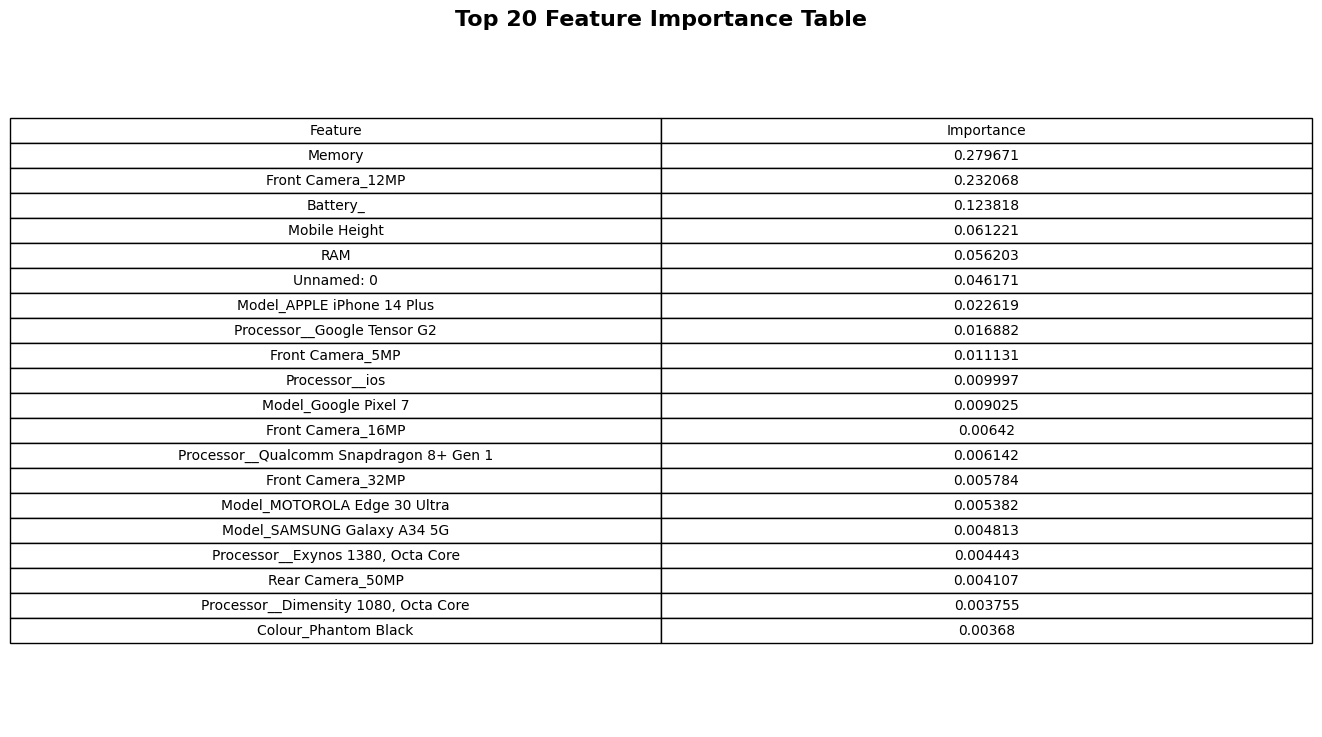

ModuleNotFoundError: No module named 'openpyxl'

<Figure size 640x480 with 0 Axes>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Create DataFrame Manually
# -----------------------------
data = {
    "Feature": [
        "Memory",
        "Front Camera_12MP",
        "Battery_",
        "Mobile Height",
        "RAM",
        "Unnamed: 0",
        "Model_APPLE iPhone 14 Plus",
        "Processor__Google Tensor G2",
        "Front Camera_5MP",
        "Processor__ios",
        "Model_Google Pixel 7",
        "Front Camera_16MP",
        "Processor__Qualcomm Snapdragon 8+ Gen 1",
        "Front Camera_32MP",
        "Model_MOTOROLA Edge 30 Ultra",
        "Model_SAMSUNG Galaxy A34 5G",
        "Processor__Exynos 1380, Octa Core",
        "Rear Camera_50MP",
        "Processor__Dimensity 1080, Octa Core",
        "Colour_Phantom Black"
    ],
    
    "Importance": [
        0.279671,
        0.232068,
        0.123818,
        0.061221,
        0.056203,
        0.046171,
        0.022619,
        0.016882,
        0.011131,
        0.009997,
        0.009025,
        0.006420,
        0.006142,
        0.005784,
        0.005382,
        0.004813,
        0.004443,
        0.004107,
        0.003755,
        0.003680
    ]
}

# Create DataFrame
table_df = pd.DataFrame(data)

# Display DataFrame
print(table_df)

# -----------------------------
# Plot Table
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 9))

# Remove axes
ax.axis('off')

# Create table
table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Title
plt.title('Top 20 Feature Importance Table', fontsize=16, fontweight='bold')

# Show
plt.show()

# -----------------------------
# Save Outputs
# -----------------------------
plt.savefig("feature_importance_table.png", dpi=300, bbox_inches='tight')

table_df.to_csv("feature_importance_table.csv", index=False)
table_df.to_excel("feature_importance_table.xlsx", index=False)

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Train-test split using encoded data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression model
lr = LinearRegression()

# Train model
lr.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [53]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [54]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

GradientBoostingRegressor()

In [55]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [56]:
y_pred = rf.predict(X_test)

In [57]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2 Score:', r2)

MAE: 1789.5189000655307
RMSE: 4760.9485179953945
R2 Score: 0.8355438324180509


In [59]:
importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
})

# Sort importance
importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head(20))

                                   Feature  Importance
0                                   Memory    0.266013
2                                 Battery_    0.136376
1                                      RAM    0.111235
4                            Mobile Height    0.080364
479                      Front Camera_12MP    0.072532
6               Model_APPLE iPhone 14 Plus    0.058674
8                     Model_Google Pixel 7    0.022547
505            Processor__Google Tensor G2    0.021699
484                      Front Camera_32MP    0.016063
466                       Rear Camera_12MP    0.012626
487                       Front Camera_5MP    0.012157
491                      Processor__6 Core    0.009411
610                         Processor__ios    0.008120
481                      Front Camera_16MP    0.007336
478                      Front Camera_10MP    0.007119
371                   Colour_Phantom Black    0.006897
113            Model_SAMSUNG Galaxy A34 5G    0.006751
512       

Top Important Features:

                                   Feature  Importance
0                                   Memory    0.266013
2                                 Battery_    0.136376
1                                      RAM    0.111235
4                            Mobile Height    0.080364
479                      Front Camera_12MP    0.072532
6               Model_APPLE iPhone 14 Plus    0.058674
8                     Model_Google Pixel 7    0.022547
505            Processor__Google Tensor G2    0.021699
484                      Front Camera_32MP    0.016063
466                       Rear Camera_12MP    0.012626
487                       Front Camera_5MP    0.012157
491                      Processor__6 Core    0.009411
610                         Processor__ios    0.008120
481                      Front Camera_16MP    0.007336
478                      Front Camera_10MP    0.007119
371                   Colour_Phantom Black    0.006897
113            Model_SAMSUNG Galaxy A34 

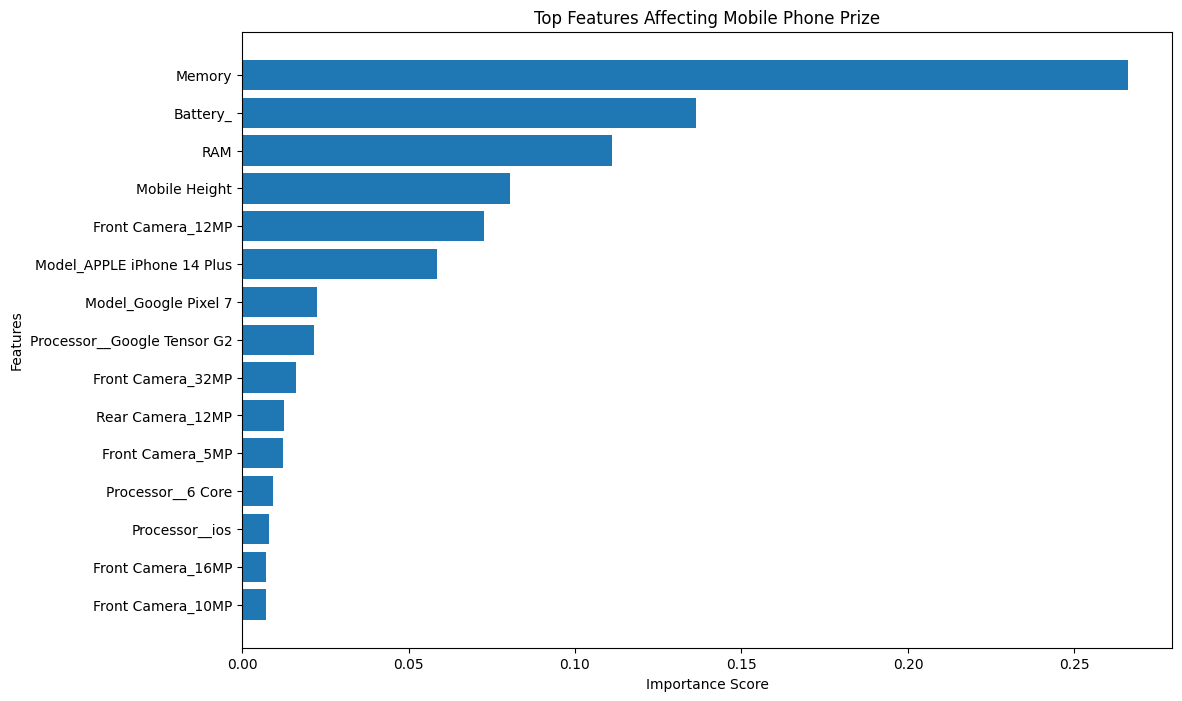

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance dataframe
importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
})

# Sort descending
importance = importance.sort_values(by='Importance', ascending=False)

# Print top 20 features
print("Top Important Features:\n")
print(importance.head(20))

# Plot top 15 features
plt.figure(figsize=(12,8))

plt.barh(
    importance['Feature'][:15],
    importance['Importance'][:15]
)

plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top Features Affecting Mobile Phone Prize')

plt.gca().invert_yaxis()

plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("C:/Users/ramch/OneDrive/Desktop/Internship_Project/Processed_Flipdata.csv")

print(df.head())

   Unnamed: 0            Model        Colour  Memory  RAM  Battery_  \
0           0  Infinix SMART 7   Night Black      64    4      6000   
1           1  Infinix SMART 7    Azure Blue      64    4      6000   
2           2     MOTOROLA G32  Mineral Gray     128    8      5000   
3           3         POCO C50    Royal Blue      32    2      5000   
4           4  Infinix HOT 30i      Marigold     128    8      5000   

  Rear Camera Front Camera  AI Lens  Mobile Height  \
0        13MP          5MP        1          16.76   
1        13MP          5MP        1          16.76   
2        50MP         16MP        0          16.64   
3         8MP          5MP        0          16.56   
4        50MP          5MP        1          16.76   

                   Processor_   Prize  
0  Unisoc Spreadtrum SC9863A1   7,299  
1  Unisoc Spreadtrum SC9863A1   7,299  
2     Qualcomm Snapdragon 680  11,999  
3          Mediatek Helio A22   5,649  
4                         G37   8,999  


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (541, 12)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB
None


In [5]:
missing = df.isnull().sum()

print(missing)

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64


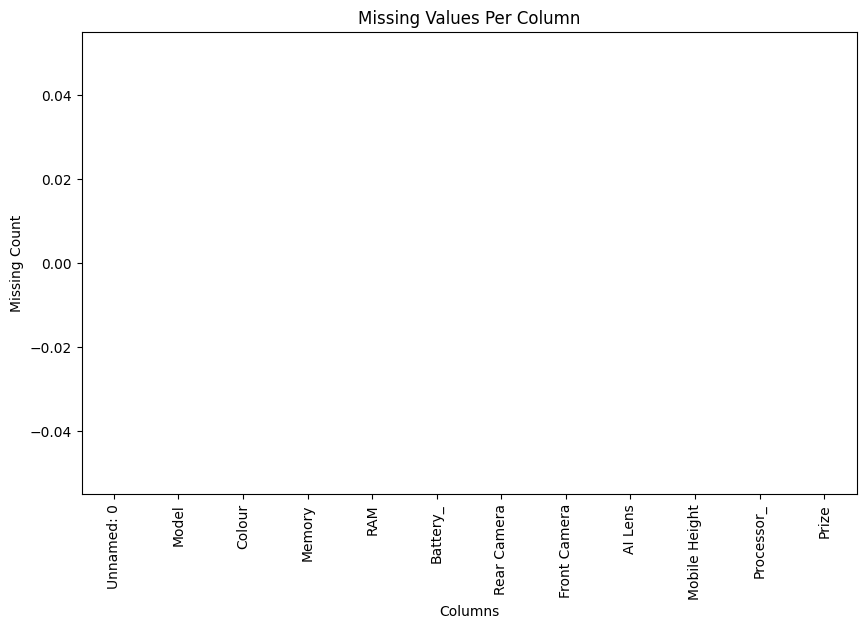

In [6]:
missing = df.isnull().sum()

plt.figure(figsize=(10,6))
missing.plot(kind='bar')

plt.title("Missing Values Per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")

plt.show()

In [7]:
print(df.describe())

       Unnamed: 0      Memory         RAM     Battery_     AI Lens  \
count  541.000000  541.000000  541.000000   541.000000  541.000000   
mean   289.711645  110.550832    5.397412  4871.587800    0.062847   
std    182.359185   60.600694    1.984923   780.148862    0.242911   
min      0.000000   16.000000    2.000000   800.000000    0.000000   
25%    135.000000   64.000000    4.000000  5000.000000    0.000000   
50%    273.000000  128.000000    6.000000  5000.000000    0.000000   
75%    434.000000  128.000000    8.000000  5000.000000    0.000000   
max    642.000000  256.000000    8.000000  7000.000000    1.000000   

       Mobile Height  
count     541.000000  
mean       16.431201  
std         2.523553  
min         4.500000  
25%        16.510000  
50%        16.710000  
75%        16.940000  
max        41.940000  


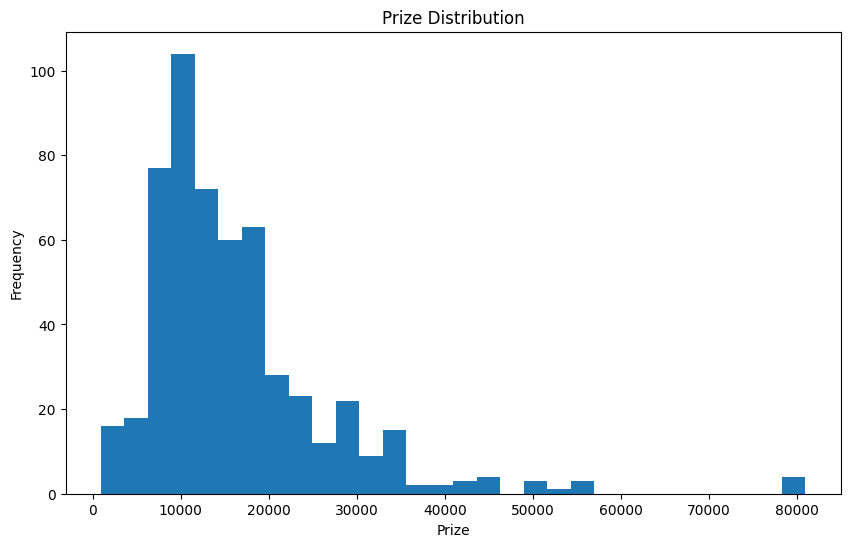

In [8]:
df['Prize'] = df['Prize'].astype(str).str.replace(',', '')
df['Prize'] = pd.to_numeric(df['Prize'])

plt.figure(figsize=(10,6))

plt.hist(df['Prize'], bins=30)

plt.title("Prize Distribution")
plt.xlabel("Prize")
plt.ylabel("Frequency")

plt.show()

In [9]:
df = df.drop('Unnamed: 0', axis=1)

print(df.head())

             Model        Colour  Memory  RAM  Battery_ Rear Camera  \
0  Infinix SMART 7   Night Black      64    4      6000        13MP   
1  Infinix SMART 7    Azure Blue      64    4      6000        13MP   
2     MOTOROLA G32  Mineral Gray     128    8      5000        50MP   
3         POCO C50    Royal Blue      32    2      5000         8MP   
4  Infinix HOT 30i      Marigold     128    8      5000        50MP   

  Front Camera  AI Lens  Mobile Height                  Processor_  Prize  
0          5MP        1          16.76  Unisoc Spreadtrum SC9863A1   7299  
1          5MP        1          16.76  Unisoc Spreadtrum SC9863A1   7299  
2         16MP        0          16.64     Qualcomm Snapdragon 680  11999  
3          5MP        0          16.56          Mediatek Helio A22   5649  
4          5MP        1          16.76                         G37   8999  


In [10]:
y = df['Prize']
X = df.drop('Prize', axis=1)

print(X.head())

             Model        Colour  Memory  RAM  Battery_ Rear Camera  \
0  Infinix SMART 7   Night Black      64    4      6000        13MP   
1  Infinix SMART 7    Azure Blue      64    4      6000        13MP   
2     MOTOROLA G32  Mineral Gray     128    8      5000        50MP   
3         POCO C50    Royal Blue      32    2      5000         8MP   
4  Infinix HOT 30i      Marigold     128    8      5000        50MP   

  Front Camera  AI Lens  Mobile Height                  Processor_  
0          5MP        1          16.76  Unisoc Spreadtrum SC9863A1  
1          5MP        1          16.76  Unisoc Spreadtrum SC9863A1  
2         16MP        0          16.64     Qualcomm Snapdragon 680  
3          5MP        0          16.56          Mediatek Helio A22  
4          5MP        1          16.76                         G37  


In [11]:
X_encoded = pd.get_dummies(X, drop_first=True)

print(X_encoded.shape)

(541, 612)


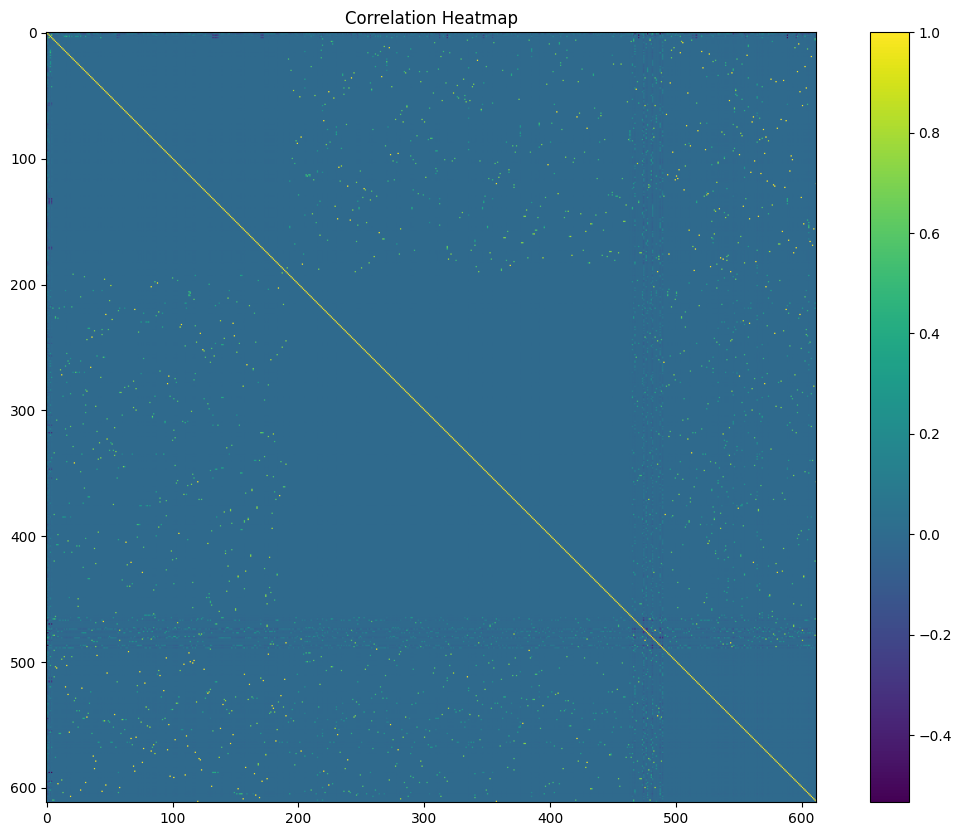

In [12]:
corr = X_encoded.corr()

plt.figure(figsize=(14,10))

plt.imshow(corr)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

In [13]:
selector = SelectKBest(score_func=f_regression, k=10)

X_new = selector.fit_transform(X_encoded, y)

selected_features = X_encoded.columns[selector.get_support()]

print(selected_features)

Index(['Memory', 'RAM', 'Model_APPLE iPhone 14 Plus', 'Rear Camera_12MP',
       'Rear Camera_8MP', 'Front Camera_12MP', 'Front Camera_32MP',
       'Front Camera_5MP', 'Processor__Google Tensor G2', 'Processor__ios'],
      dtype='object')


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(432, 612)
(109, 612)


In [15]:
lr = LinearRegression()

lr.fit(X_train, y_train)

print("Linear Regression Model Trained")

Linear Regression Model Trained


In [16]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

print("Random Forest Model Trained")

Random Forest Model Trained


In [17]:
y_pred = rf.predict(X_test)

print(y_pred[:10])

[ 8509.    6597.07 19359.08 10885.83 13204.89 14428.91  9805.46 15981.69
 30107.17  9172.21]


In [18]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Value': [mae, rmse, r2]
})

print(metrics)

     Metric        Value
0       MAE  1804.116165
1      RMSE  4797.204511
2  R2 Score     0.833030


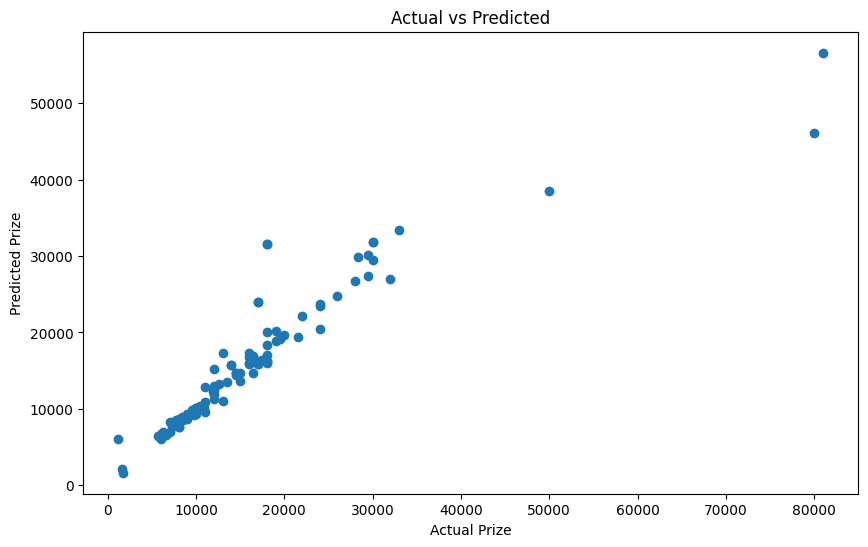

In [19]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prize")
plt.ylabel("Predicted Prize")
plt.title("Actual vs Predicted")

plt.show()

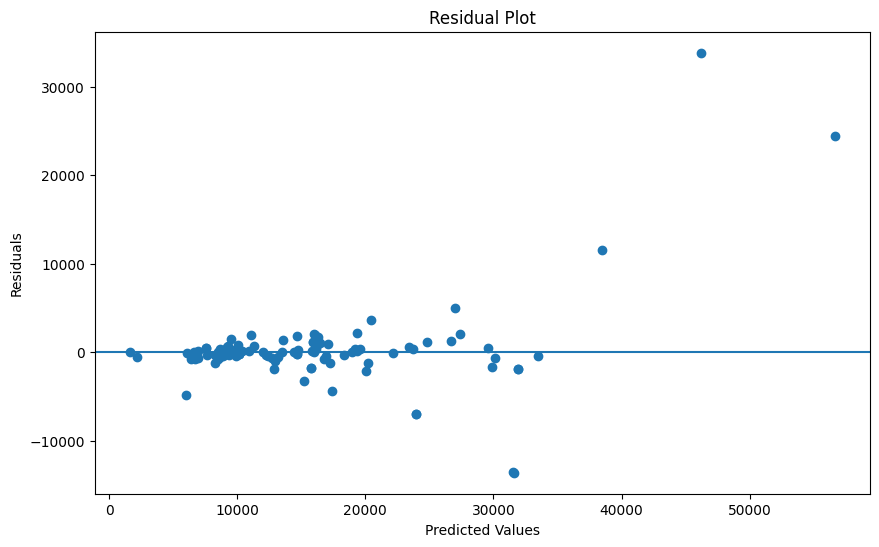

In [20]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [21]:
importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head(20))

                                   Feature  Importance
0                                   Memory    0.279328
2                                 Battery_    0.155498
1                                      RAM    0.094360
4                            Mobile Height    0.076815
479                      Front Camera_12MP    0.070309
6               Model_APPLE iPhone 14 Plus    0.054474
505            Processor__Google Tensor G2    0.020632
8                     Model_Google Pixel 7    0.017371
484                      Front Camera_32MP    0.013938
487                       Front Camera_5MP    0.012824
466                       Rear Camera_12MP    0.009276
491                      Processor__6 Core    0.008855
610                         Processor__ios    0.008504
371                   Colour_Phantom Black    0.007160
481                      Front Camera_16MP    0.006884
383                          Colour_Purple    0.006872
588                     Processor__SC6531E    0.006539
334       

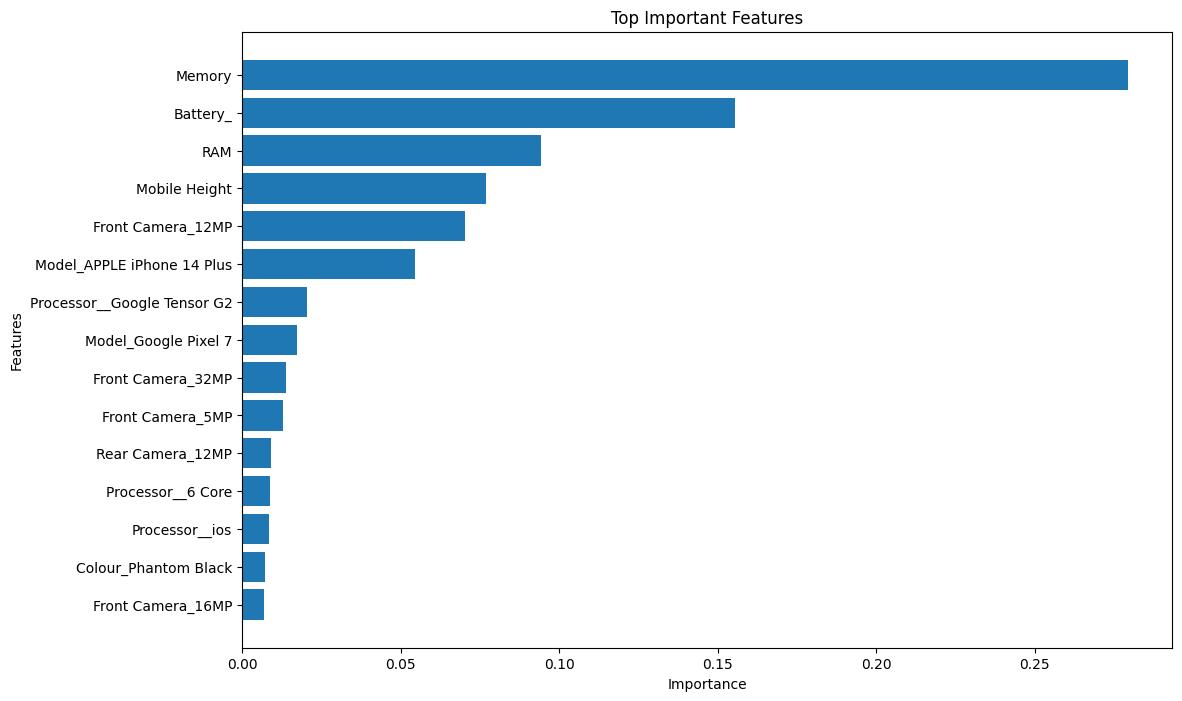

In [22]:
top_features = importance.head(15)

plt.figure(figsize=(12,8))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top Important Features")

plt.gca().invert_yaxis()

plt.show()

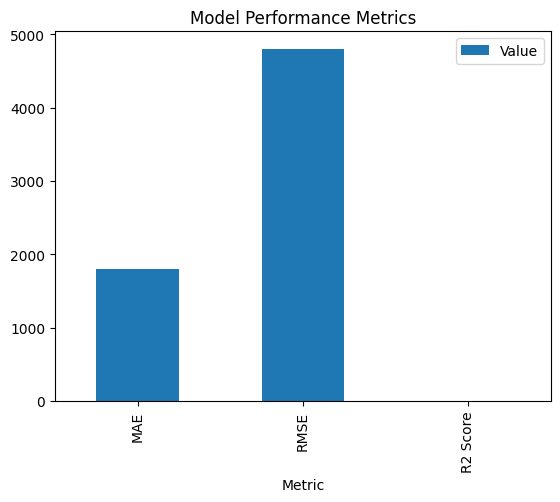

In [23]:
metrics.plot(x='Metric', y='Value', kind='bar')

plt.title("Model Performance Metrics")

plt.show()

In [24]:
plt.savefig("plot_name.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [25]:
importance.to_csv("feature_importance.csv", index=False)

In [26]:
metrics.to_csv("model_metrics.csv", index=False)

In [29]:
import os

# Create folders automatically
os.makedirs("outputs/plots", exist_ok=True)

# Save figure
plt.savefig("outputs/plots/feature_importance.png",
            dpi=300,
            bbox_inches='tight')

print("Plot saved successfully")

Plot saved successfully


<Figure size 640x480 with 0 Axes>

In [32]:
plt.savefig(r"C:\Users\ramch\Documents\feature_importance.png",
            dpi=300,
            bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [33]:
plt.savefig("feature_importance.png",
            dpi=300,
            bbox_inches='tight')

<Figure size 640x480 with 0 Axes>